Vocabulary size: 9132
Testing LR=1e-05, Dropout=0.2
Epoch 1 Train Loss: 0.6649 | Val Loss: 0.6214 | Val Acc: 64.36
Epoch 2 Train Loss: 0.5656 | Val Loss: 0.5357 | Val Acc: 71.72
Epoch 3 Train Loss: 0.5189 | Val Loss: 0.5119 | Val Acc: 74.60
Epoch 4 Train Loss: 0.4880 | Val Loss: 0.4915 | Val Acc: 75.80
Epoch 5 Train Loss: 0.4603 | Val Loss: 0.4732 | Val Acc: 77.32
Epoch 6 Train Loss: 0.4408 | Val Loss: 0.4599 | Val Acc: 78.00
Epoch 7 Train Loss: 0.4247 | Val Loss: 0.4501 | Val Acc: 79.04
Epoch 8 Train Loss: 0.4114 | Val Loss: 0.4410 | Val Acc: 79.32
Epoch 9 Train Loss: 0.4021 | Val Loss: 0.4333 | Val Acc: 79.68
Epoch 10 Train Loss: 0.3895 | Val Loss: 0.4260 | Val Acc: 80.64
Epoch 11 Train Loss: 0.3802 | Val Loss: 0.4205 | Val Acc: 81.16
Epoch 12 Train Loss: 0.3723 | Val Loss: 0.4148 | Val Acc: 80.88
Epoch 13 Train Loss: 0.3641 | Val Loss: 0.4083 | Val Acc: 81.48
Epoch 14 Train Loss: 0.3555 | Val Loss: 0.4023 | Val Acc: 82.00
Epoch 15 Train Loss: 0.3480 | Val Loss: 0.3970 | Val Acc: 82.

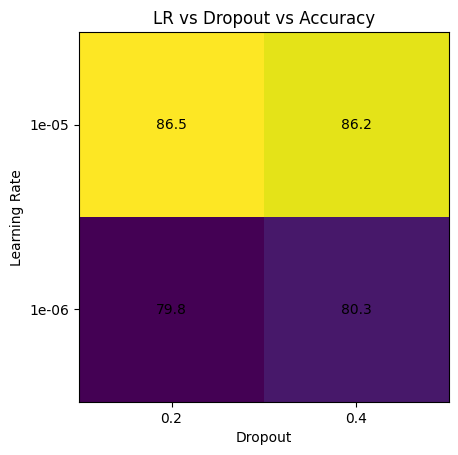

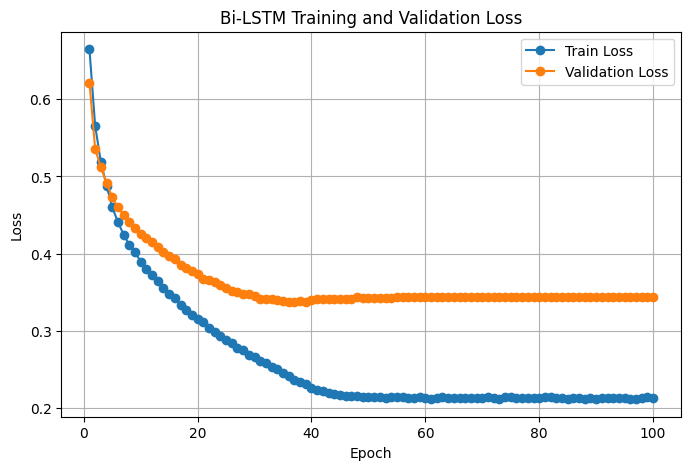

Best Config: (1e-05, 0.2)
Test Accuracy: 86.56


In [1]:
# =========================
# 1. Imports
# =========================
import pandas as pd
import numpy as np
import re
from collections import Counter

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# =========================
# 2. Load Data
# =========================
data = pd.read_csv("amazon_cells_labelled_LARGE_25K.txt", delimiter='	', header=None)
data.columns = ['Sentence', 'Class']

data['Sentence'] = data['Sentence'].astype(str).str.strip()
texts = data['Sentence'].tolist()
labels = data['Class'].tolist()


# =========================
# 3. Split Data
# =========================
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.2, stratify=labels, random_state=SEED
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, stratify=temp_labels, random_state=SEED
)


# =========================
# 4. Tokenization and Vocabulary
# =========================
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
MAX_VOCAB_SIZE = 20000
MIN_FREQ = 2
MAX_SEQ_LEN = 128


def clean_text(text):
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def build_vocab(sentences, min_freq=MIN_FREQ, max_size=MAX_VOCAB_SIZE):
    counter = Counter()
    for sentence in sentences:
        counter.update(sentence.split())
    tokens = [tok for tok, freq in counter.most_common(max_size) if freq >= min_freq]
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for idx, token in enumerate(tokens, start=2):
        vocab[token] = idx
    return vocab


def encode_sentence(sentence, vocab, max_len=MAX_SEQ_LEN):
    tokens = sentence.split()
    token_ids = [vocab.get(token, vocab[UNK_TOKEN]) for token in tokens[:max_len]]
    if len(token_ids) < max_len:
        token_ids += [vocab[PAD_TOKEN]] * (max_len - len(token_ids))
    return token_ids


train_texts = [clean_text(text) for text in train_texts]
val_texts = [clean_text(text) for text in val_texts]
test_texts = [clean_text(text) for text in test_texts]

vocab = build_vocab(train_texts)
pad_idx = vocab[PAD_TOKEN]
unk_idx = vocab[UNK_TOKEN]
vocab_size = len(vocab)
print('Vocabulary size:', vocab_size)


# =========================
# 5. Dataset
# =========================
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.inputs = [torch.tensor(encode_sentence(text, vocab), dtype=torch.long) for text in texts]
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.inputs[idx], self.labels[idx]


batch_size = 16
train_loader = DataLoader(TextDataset(train_texts, train_labels, vocab), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TextDataset(val_texts, val_labels, vocab), batch_size=batch_size)
test_loader = DataLoader(TextDataset(test_texts, test_labels, vocab), batch_size=batch_size)


# =========================
# 6. Model
# =========================
class Tunable_BiLSTM_Attention(nn.Module):
    def __init__(self, vocab_size, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 128, padding_idx=pad_idx)
        self.lstm = nn.LSTM(128, 128, batch_first=True, bidirectional=True)
        self.attention = nn.Sequential(
            nn.Linear(256, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )
        self.norm = nn.LayerNorm(256)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(256, 1)

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, _ = self.lstm(x)
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)
        context = self.norm(context)
        out = self.dropout(context)
        out = self.fc(out)
        return out.squeeze()


# =========================
# 7. Evaluation
# =========================
def evaluate(model, loader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == y).sum().item()
            total += y.size(0)

    return 100 * correct / total


# =========================
# 8. Training
# =========================
def train_model(model, lr, epochs=100):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    criterion = nn.BCEWithLogitsLoss()

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        val_loss = 0
        correct = 0
        total = 0
        model.eval()
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                val_loss += loss.item()
                preds = (torch.sigmoid(outputs) > 0.5).float()
                correct += (preds == y).sum().item()
                total += y.size(0)

        avg_train_loss = total_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct / total
        scheduler.step(avg_val_loss)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1} Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}")

    return val_acc, model, train_losses, val_losses


# =========================
# 9. Grid Search
learning_rates = [0.00001, 0.000001]
dropouts = [0.2, 0.4]

results_matrix = np.zeros((len(learning_rates), len(dropouts)))

best_acc = 0
best_model = None
best_config = None

for i, lr in enumerate(learning_rates):
    for j, d in enumerate(dropouts):
        print(f"Testing LR={lr}, Dropout={d}")
        model = Tunable_BiLSTM_Attention(vocab_size=vocab_size, dropout=d)
        val_acc, trained_model, tr_losses, vl_losses = train_model(model, lr)
        results_matrix[i][j] = val_acc
        if val_acc > best_acc:
            best_acc = val_acc
            best_model = trained_model
            best_config = (lr, d)
            best_train_losses = tr_losses
            best_val_losses = vl_losses


# =========================
# 10. Heatmap
plt.imshow(results_matrix)
plt.xticks(range(len(dropouts)), dropouts)
plt.yticks(range(len(learning_rates)), learning_rates)
plt.xlabel("Dropout")
plt.ylabel("Learning Rate")
plt.title("LR vs Dropout vs Accuracy")
for i in range(len(learning_rates)):
    for j in range(len(dropouts)):
        plt.text(j, i, f"{results_matrix[i][j]:.1f}", ha='center', va='center')
plt.show()


# =========================
# 11. Loss Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, 101), best_train_losses, label='Train Loss', marker='o')
plt.plot(range(1, 101), best_val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Bi-LSTM Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 12. Final Test
print(f"Best Config: {best_config}")
test_acc = evaluate(best_model, test_loader)
print("Test Accuracy:", test_acc)